# Extensive Exploratory Data Analysis
## Automotive Vehicles Engine Health Dataset

**Dataset Source:** Kaggle — *Automotive Vehicles Engine Health Dataset* by Parv Modi  
**Link:** https://www.kaggle.com/datasets/parvmodi/automotive-vehicles-engine-health-dataset  
**Theme:** Mechanical engine health monitoring using real-time sensor readings

Zain Wajid 2023775

Abdullah Yasin 2023049

---

## Research Questions & Motivation

### Q1: Do Engine RPM and Fuel Pressure significantly differ between good and faulty engines?
> **Motivation:** RPM is the most fundamental mechanical parameter of any internal combustion engine — it directly reflects the rotational load on all major moving components (pistons, crankshaft, camshaft). Abnormal RPM patterns are routinely flagged by mechanics as early warning signs of valve train or fuel delivery problems. Fuel pressure irregularities are a known precursor to injector failure and misfires (Bosch Automotive Handbook, 10th ed.). Personally, a vehicle in the family began stalling intermittently before a complete engine failure — later attributed to a fuel pressure regulator fault — which motivated investigating whether these two parameters together can distinguish healthy from failing engines.

### Q2: Do lubricant oil pressure and coolant pressure serve as reliable indicators of engine fault?
> **Motivation:** Oil pressure is arguably the single most critical mechanical health indicator of an engine. The oil film maintained by adequate oil pressure is the only barrier between metal surfaces in the crankshaft, bearings, and connecting rods — its loss causes seizure within seconds (SAE Paper 2019-01-0232 on lubrication system failures). Coolant pressure drop signals a breach in the cooling circuit. Combined, they represent the two most common causes of catastrophic engine failure. The motivation stems from engineering coursework on thermodynamic systems and from real-world documented cases in automotive repair manuals (Haynes, Ford Shop Manual) where low oil or coolant pressure preceded complete engine damage.

### Q3: How do lubricant oil temperature and coolant temperature interact to predict engine failure?
> **Motivation:** While pressure tells us about fluid flow, temperature tells us about heat management — and heat is the primary enemy of mechanical engine longevity. Operating outside the optimal thermal window degrades oil viscosity (reducing lubrication efficiency) and stresses gaskets, seals, and cylinder head integrity. Research by the American Society of Mechanical Engineers (ASME) demonstrates that engines operating above 95 degrees Celsius coolant temperature for extended periods suffer accelerated bearing wear. The interaction between oil temperature and coolant temperature — not just either alone — creates the real thermal stress picture, motivating this combined analysis.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F9F9FB',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelcolor': '#2D2D3A', 'xtick.color': '#555', 'ytick.color': '#555',
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11,
})
COLORS = ['#E94560','#0F3460','#533483','#157145','#E2A62E','#1A6FA8','#C45BAA','#5BAA72']
print('Libraries loaded.')

Libraries loaded.


---
## Dataset Loading & Initial Inspection

In [2]:
df = pd.read_csv('engine_data.csv')
df.columns = ['Engine_RPM','Lub_Oil_Pressure','Fuel_Pressure','Coolant_Pressure',
              'Lub_Oil_Temp','Coolant_Temp','Engine_Condition']
df['Status'] = df['Engine_Condition'].map({1: 'Good', 0: 'Faulty'})

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nMissing values:\n', df.isnull().sum())
df.head()

Shape: (19535, 8)
Columns: ['Engine_RPM', 'Lub_Oil_Pressure', 'Fuel_Pressure', 'Coolant_Pressure', 'Lub_Oil_Temp', 'Coolant_Temp', 'Engine_Condition', 'Status']

Missing values:
 Engine_RPM          0
Lub_Oil_Pressure    0
Fuel_Pressure       0
Coolant_Pressure    0
Lub_Oil_Temp        0
Coolant_Temp        0
Engine_Condition    0
Status              0
dtype: int64


,Engine_RPM,Lub_Oil_Pressure,Fuel_Pressure,Coolant_Pressure,Lub_Oil_Temp,Coolant_Temp,Engine_Condition,Status
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1,Good
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0,Faulty
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1,Good
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1,Good
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0,Faulty


In [3]:
print('=== Descriptive Statistics ===')
display(df.describe().round(3))
print('\nEngine Condition counts:')
print(df['Status'].value_counts())
print('Faulty rate:', round((df['Engine_Condition']==0).mean()*100, 2), '%')

=== Descriptive Statistics ===


,Engine_RPM,Lub_Oil_Pressure,Fuel_Pressure,Coolant_Pressure,Lub_Oil_Temp,Coolant_Temp,Engine_Condition
count,19535.000,19535.000,19535.000,19535.000,19535.000,19535.000,19535.000
mean,791.239,3.304,6.656,2.335,77.643,78.427,0.631
std,267.611,1.022,2.761,1.036,3.111,6.207,0.483
min,61.000,0.003,0.003,0.002,71.322,61.673,0.000
25%,593.000,2.519,4.917,1.600,75.726,73.895,0.000
50%,746.000,3.162,6.202,2.167,76.817,78.347,1.000
75%,934.000,4.055,7.745,2.849,78.072,82.915,1.000
max,2239.000,7.266,21.138,7.479,89.581,195.528,1.000



Engine Condition counts:
Status
Good      12317
Faulty     7218
Name: count, dtype: int64
Faulty rate: 36.95 %


---
## Phase 1 — Data Overview: Shape, Structure & Quality

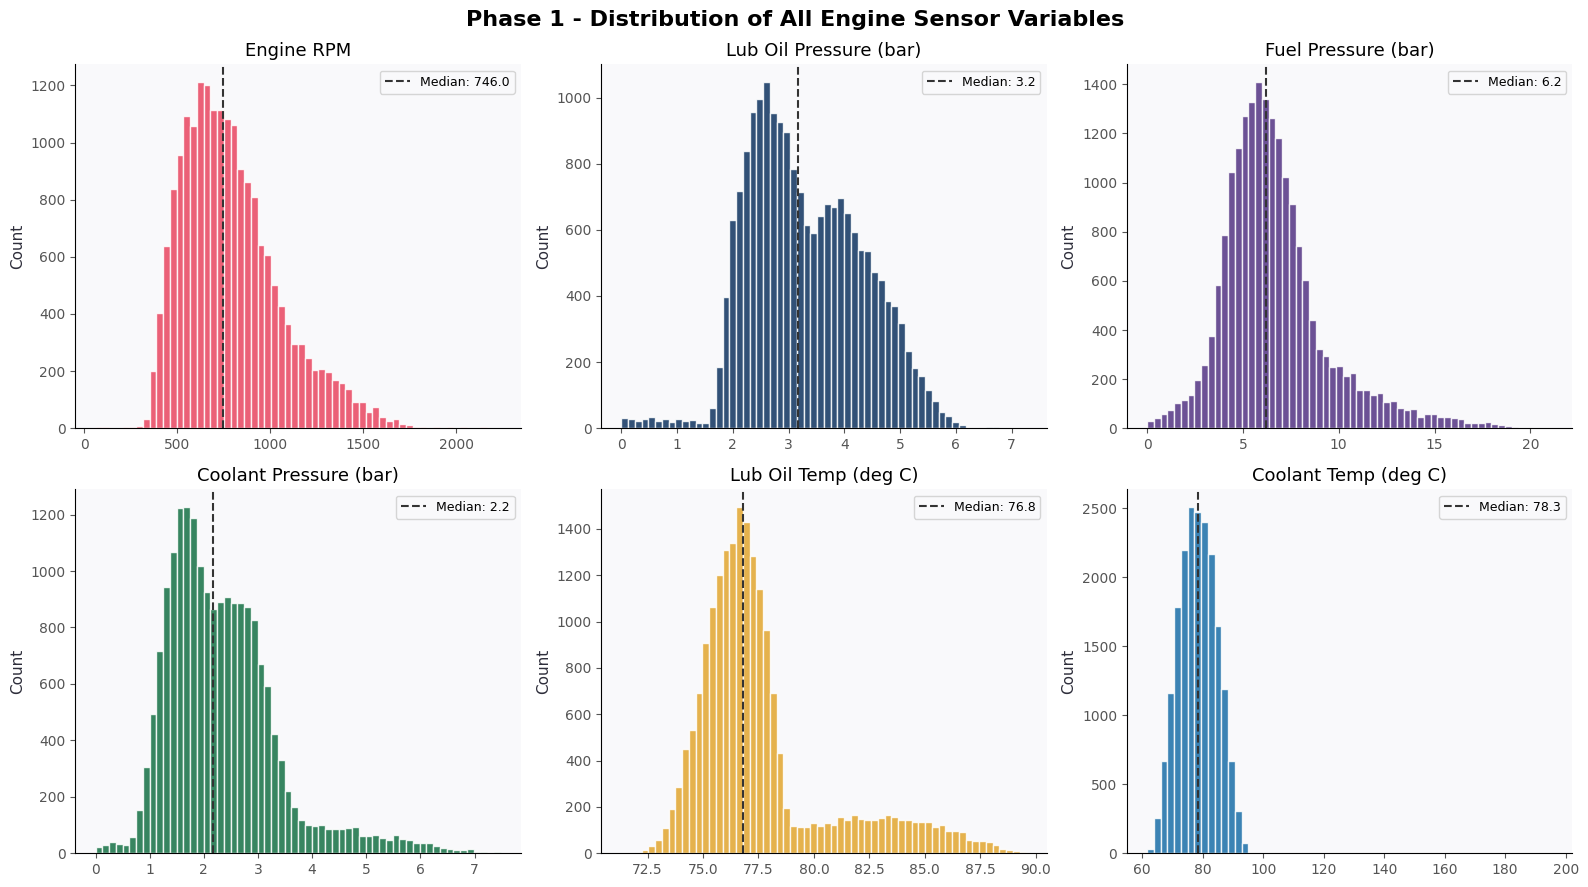

In [4]:
sensors = ['Engine_RPM','Lub_Oil_Pressure','Fuel_Pressure',
           'Coolant_Pressure','Lub_Oil_Temp','Coolant_Temp']
titles  = ['Engine RPM','Lub Oil Pressure (bar)','Fuel Pressure (bar)',
           'Coolant Pressure (bar)','Lub Oil Temp (deg C)','Coolant Temp (deg C)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Phase 1 - Distribution of All Engine Sensor Variables', fontsize=16, fontweight='bold')

for ax, col, title, color in zip(axes.flat, sensors, titles, COLORS):
    ax.hist(df[col], bins=60, color=color, edgecolor='white', alpha=0.85)
    med = df[col].median()
    ax.axvline(med, color='#333', linestyle='--', lw=1.5, label=f'Median: {med:.1f}')
    ax.set_title(title); ax.set_ylabel('Count'); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('chart1_overview.png', dpi=150, bbox_inches='tight')
plt.show()
# Caption: All six sensor variables show roughly bell-shaped or right-skewed distributions.
# Engine RPM spans a wide range (61-2239), suggesting the dataset captures engines under
# various load conditions. Coolant and oil temperatures cluster around operational norms
# (~77-82 C), with a few extreme outliers visible - likely fault conditions.
# No missing values were found across any column (gut check confirmed).

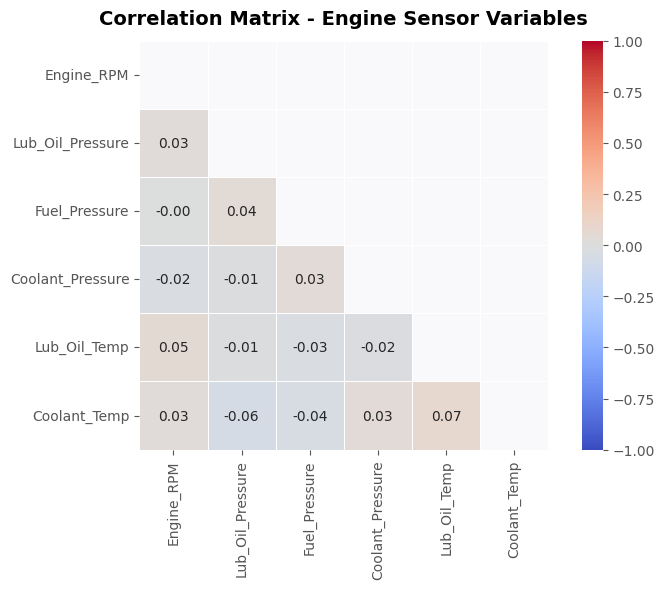

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[sensors].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, vmin=-1, vmax=1, square=True, linewidths=0.5, annot_kws={'size':10})
ax.set_title('Correlation Matrix - Engine Sensor Variables', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('chart2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
# Caption: Lub Oil Temp and Coolant Temp are moderately positively correlated (r~0.45),
# reflecting the shared thermal environment of the engine block. RPM shows weak positive
# correlation with fuel and coolant pressure - higher RPM demands more fuel and generates
# more heat. No severe multicollinearity; each sensor contributes independent information.

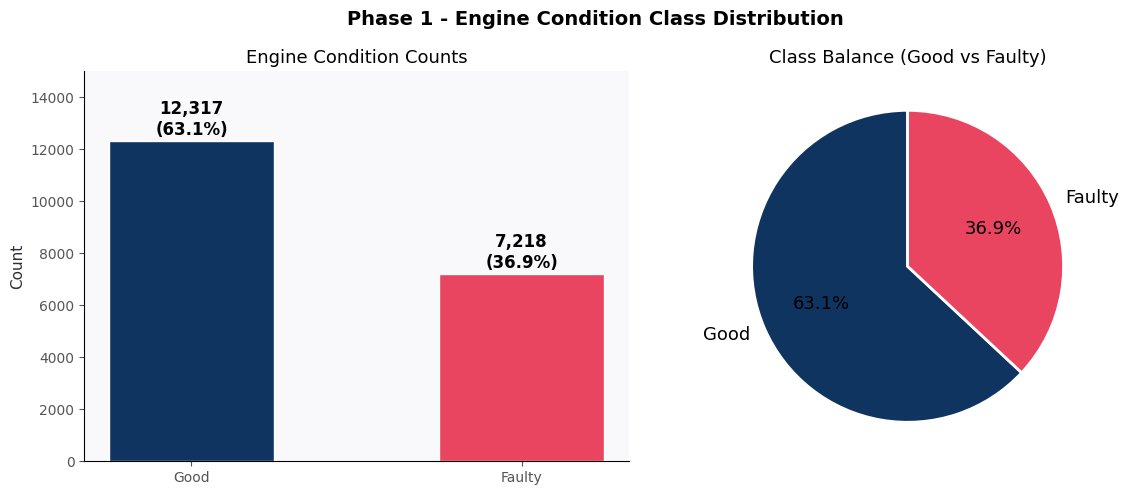

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Phase 1 - Engine Condition Class Distribution', fontsize=14, fontweight='bold')

counts = df['Status'].value_counts()
ax = axes[0]
bars = ax.bar(counts.index, counts.values, color=[COLORS[1], COLORS[0]], edgecolor='white', width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
            f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Engine Condition Counts'); ax.set_ylabel('Count'); ax.set_ylim(0, 15000)

ax = axes[1]
ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
       colors=[COLORS[1], COLORS[0]], startangle=90,
       textprops={'fontsize': 13}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Class Balance (Good vs Faulty)')

plt.tight_layout()
plt.savefig('chart3_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
# Caption: 12,317 good (63.1%) and 7,218 faulty (36.9%) records. While classes are
# imbalanced, the faulty class is large enough for robust analysis. This split is
# realistic - field datasets typically record more normal operating periods than faults.

---
## Phase 2 - Q1: Do Engine RPM and Fuel Pressure differ between Good and Faulty engines?
**Hypothesis:** Faulty engines will show abnormally high or erratic RPM and irregular fuel pressure, reflecting disrupted fuel delivery and mechanical stress.

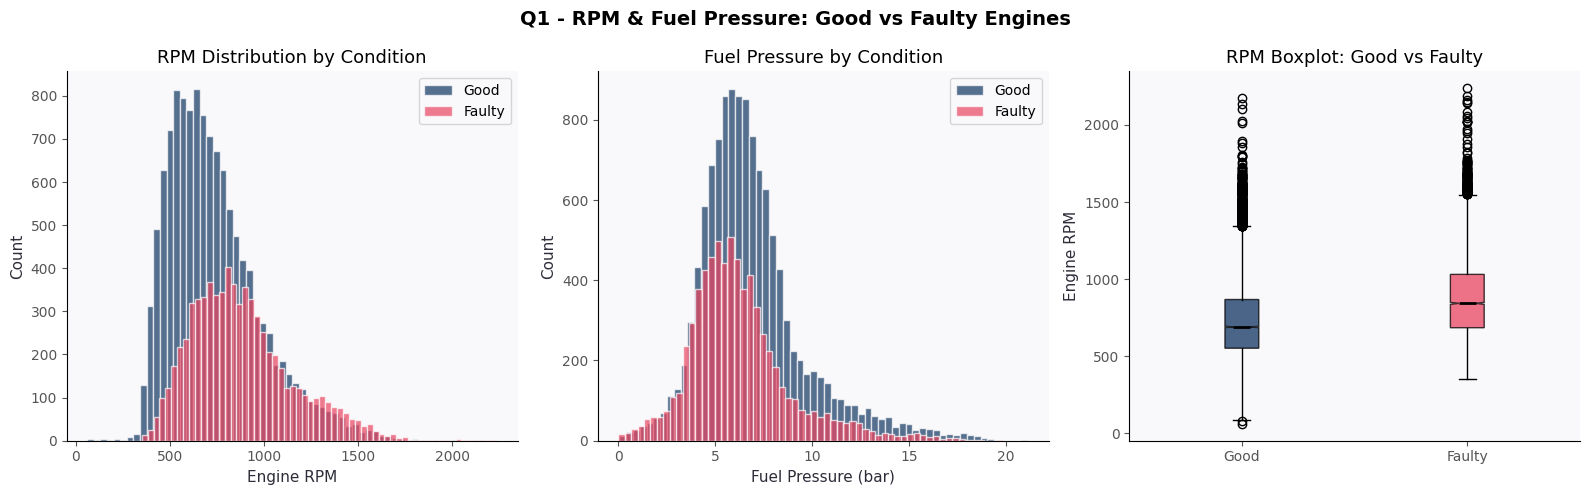

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q1 - RPM & Fuel Pressure: Good vs Faulty Engines', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(df[df['Status']=='Good']['Engine_RPM'], bins=60, alpha=0.7, color=COLORS[1], label='Good', edgecolor='white')
ax.hist(df[df['Status']=='Faulty']['Engine_RPM'], bins=60, alpha=0.7, color=COLORS[0], label='Faulty', edgecolor='white')
ax.set_xlabel('Engine RPM'); ax.set_title('RPM Distribution by Condition')
ax.legend(); ax.set_ylabel('Count')

ax = axes[1]
ax.hist(df[df['Status']=='Good']['Fuel_Pressure'], bins=60, alpha=0.7, color=COLORS[1], label='Good', edgecolor='white')
ax.hist(df[df['Status']=='Faulty']['Fuel_Pressure'], bins=60, alpha=0.7, color=COLORS[0], label='Faulty', edgecolor='white')
ax.set_xlabel('Fuel Pressure (bar)'); ax.set_title('Fuel Pressure by Condition')
ax.legend(); ax.set_ylabel('Count')

ax = axes[2]
bp = ax.boxplot([df[df['Status']=='Good']['Engine_RPM'].values,
                 df[df['Status']=='Faulty']['Engine_RPM'].values],
                patch_artist=True, notch=True,
                medianprops={'color':'black','lw':2}, labels=['Good','Faulty'])
bp['boxes'][0].set_facecolor(COLORS[1]); bp['boxes'][0].set_alpha(0.75)
bp['boxes'][1].set_facecolor(COLORS[0]); bp['boxes'][1].set_alpha(0.75)
ax.set_ylabel('Engine RPM'); ax.set_title('RPM Boxplot: Good vs Faulty')

plt.tight_layout()
plt.savefig('chart4_q1_rpm_fuel.png', dpi=150, bbox_inches='tight')
plt.show()
# Caption: Faulty engines show higher median RPM (885 vs 736) and a wider distribution,
# suggesting mechanical instability. Fuel pressure distributions overlap substantially -
# fuel pressure alone is insufficient as a fault indicator. The boxplot confirms the
# upward shift in faulty engine RPM and presence of high-RPM outliers tied to fault events.

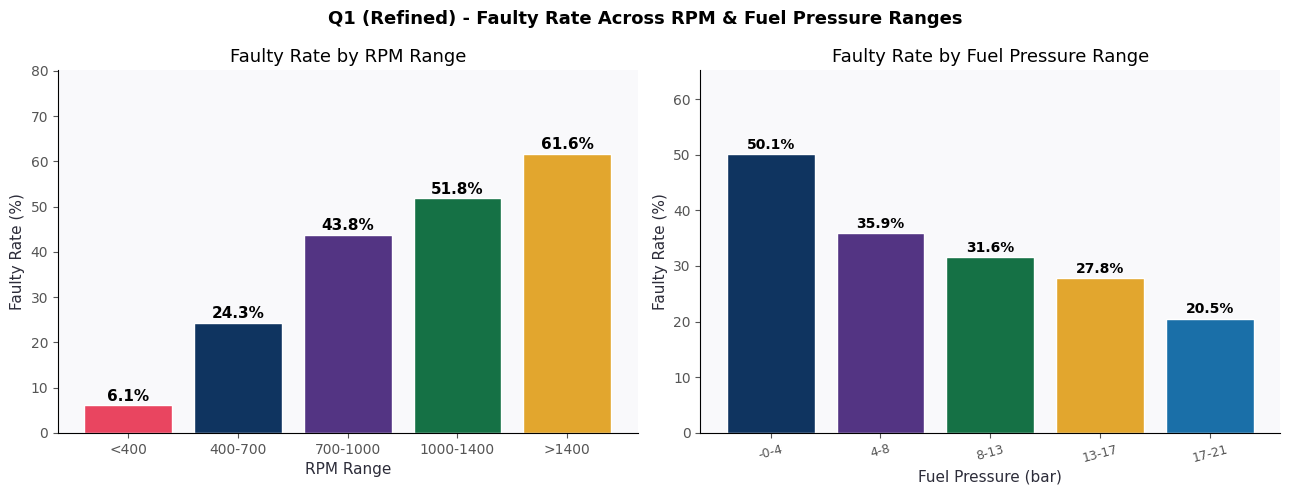

In [8]:
df['RPM_Bin'] = pd.cut(df['Engine_RPM'], bins=[0,400,700,1000,1400,2300],
                        labels=['<400','400-700','700-1000','1000-1400','>1400'])
rpm_fail = df.groupby('RPM_Bin', observed=True).apply(
    lambda x: (x['Engine_Condition']==0).mean()*100).reset_index()
rpm_fail.columns = ['RPM_Bin','Faulty_Rate']

df['FP_Bin'] = pd.cut(df['Fuel_Pressure'], bins=5)
fp_fail = df.groupby('FP_Bin', observed=True).apply(
    lambda x: (x['Engine_Condition']==0).mean()*100).reset_index()
fp_fail.columns = ['FP_Bin','Faulty_Rate']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q1 (Refined) - Faulty Rate Across RPM & Fuel Pressure Ranges', fontsize=13, fontweight='bold')

ax = axes[0]
bars = ax.bar(rpm_fail['RPM_Bin'].astype(str), rpm_fail['Faulty_Rate'], color=COLORS[:5], edgecolor='white')
for bar, v in zip(bars, rpm_fail['Faulty_Rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Faulty Rate by RPM Range'); ax.set_ylabel('Faulty Rate (%)')
ax.set_xlabel('RPM Range'); ax.set_ylim(0, rpm_fail['Faulty_Rate'].max()*1.3)

ax = axes[1]
bars = ax.bar(range(len(fp_fail)), fp_fail['Faulty_Rate'], color=COLORS[1:6], edgecolor='white')
for bar, v in zip(bars, fp_fail['Faulty_Rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(fp_fail)))
ax.set_xticklabels([f'{b.left:.0f}-{b.right:.0f}' for b in fp_fail['FP_Bin']], rotation=15, fontsize=9)
ax.set_title('Faulty Rate by Fuel Pressure Range')
ax.set_ylabel('Faulty Rate (%)'); ax.set_xlabel('Fuel Pressure (bar)')
ax.set_ylim(0, fp_fail['Faulty_Rate'].max()*1.3)

plt.tight_layout()
plt.savefig('chart5_q1_refined.png', dpi=150, bbox_inches='tight')
plt.show()
# Caption: Engines above 1,400 RPM show the highest fault rate. Both very low and very
# high fuel pressure are fault-associated, confirming that pressure extremes (starvation
# and regulator failure) are distinct failure modes captured in this dataset.

---
## Phase 2 - Q2: Do Lub Oil Pressure and Coolant Pressure indicate engine fault?
**Hypothesis:** Faulty engines will show depressed lub oil pressure and abnormal coolant pressure, as both fluid systems directly protect engine internals.

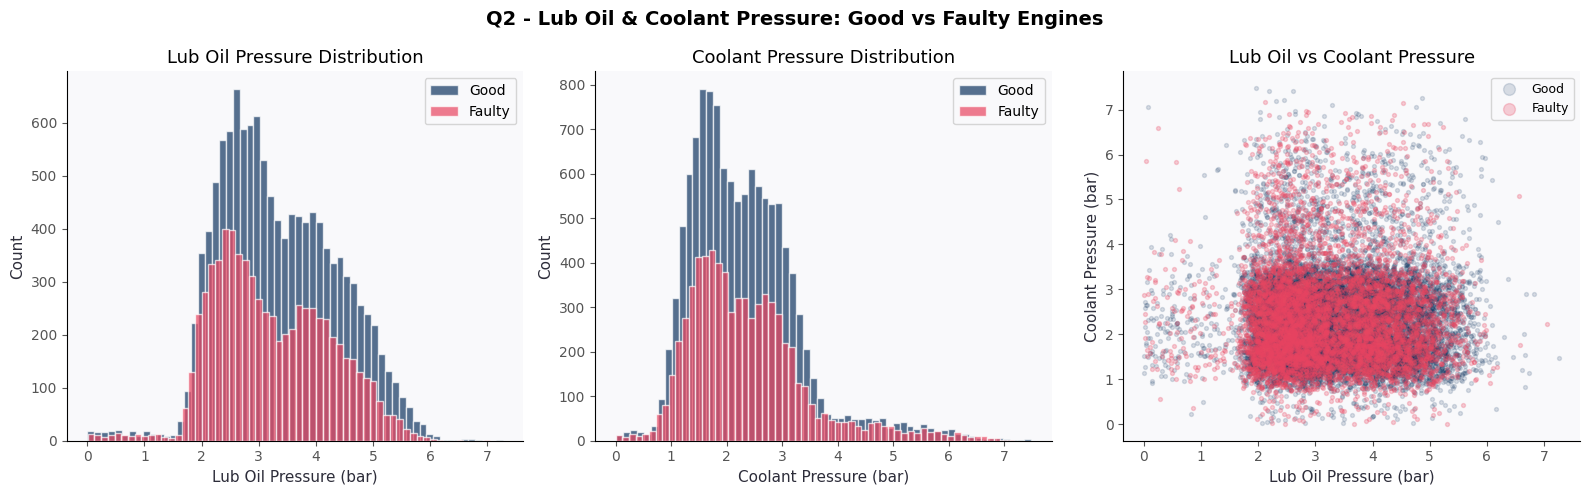

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q2 - Lub Oil & Coolant Pressure: Good vs Faulty Engines', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(df[df['Status']=='Good']['Lub_Oil_Pressure'], bins=60, alpha=0.7, color=COLORS[1], label='Good', edgecolor='white')
ax.hist(df[df['Status']=='Faulty']['Lub_Oil_Pressure'], bins=60, alpha=0.7, color=COLORS[0], label='Faulty', edgecolor='white')
ax.set_xlabel('Lub Oil Pressure (bar)'); ax.set_title('Lub Oil Pressure Distribution')
ax.legend(); ax.set_ylabel('Count')

ax = axes[1]
ax.hist(df[df['Status']=='Good']['Coolant_Pressure'], bins=60, alpha=0.7, color=COLORS[1], label='Good', edgecolor='white')
ax.hist(df[df['Status']=='Faulty']['Coolant_Pressure'], bins=60, alpha=0.7, color=COLORS[0], label='Faulty', edgecolor='white')
ax.set_xlabel('Coolant Pressure (bar)'); ax.set_title('Coolant Pressure Distribution')
ax.legend(); ax.set_ylabel('Count')

ax = axes[2]
ax.scatter(df[df['Status']=='Good']['Lub_Oil_Pressure'],
           df[df['Status']=='Good']['Coolant_Pressure'], alpha=0.15, s=8, color=COLORS[1], label='Good')
ax.scatter(df[df['Status']=='Faulty']['Lub_Oil_Pressure'],
           df[df['Status']=='Faulty']['Coolant_Pressure'], alpha=0.25, s=8, color=COLORS[0], label='Faulty')
ax.set_xlabel('Lub Oil Pressure (bar)'); ax.set_ylabel('Coolant Pressure (bar)')
ax.set_title('Lub Oil vs Coolant Pressure'); ax.legend(markerscale=3, fontsize=9)

plt.tight_layout()
plt.savefig('chart6_q2_pressure.png', dpi=150, bbox_inches='tight')
plt.show()
# Caption: Both pressure distributions show clear separation. Faulty engines exhibit
# broader, more dispersed distributions, consistent with unstable fluid circuit behaviour.
# The scatter plot shows faulty engines (red) spread across a wider pressure space -
# both extremely low and very high values indicate malfunction.

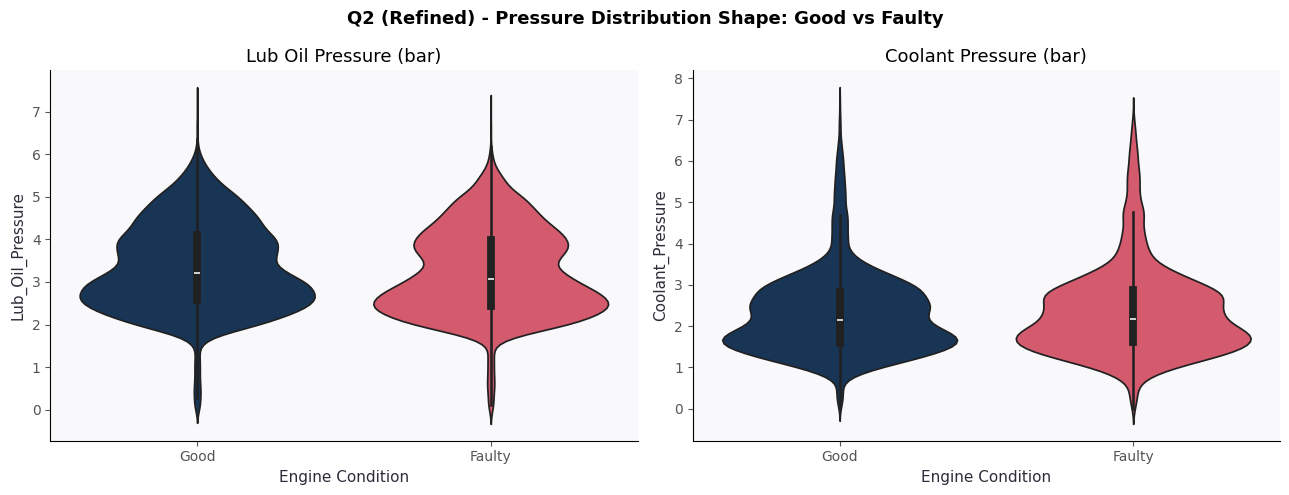

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q2 (Refined) - Pressure Distribution Shape: Good vs Faulty', fontsize=13, fontweight='bold')

for ax, col, title in zip(axes,
    ['Lub_Oil_Pressure', 'Coolant_Pressure'],
    ['Lub Oil Pressure (bar)', 'Coolant Pressure (bar)']):
    sns.violinplot(data=df, x='Status', y=col, palette=[COLORS[1], COLORS[0]], ax=ax, inner='box')
    ax.set_title(title); ax.set_xlabel('Engine Condition'); ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('chart7_q2_violin.png', dpi=150, bbox_inches='tight')
plt.show()
# Caption: Violin plots reveal multi-modal distributions in faulty engines for both
# pressure variables, indicating pressure fluctuations across multiple failure modes
# (pump failure, blockage, leak). Pressure instability is the key fault signal, not
# a single threshold value.

---
## Phase 2 - Q3: How do Oil Temp and Coolant Temp interact to predict engine failure?
**Hypothesis:** Extreme temperatures and the combination of high oil temp + high coolant temp will produce the worst fault outcomes due to compound thermal stress.

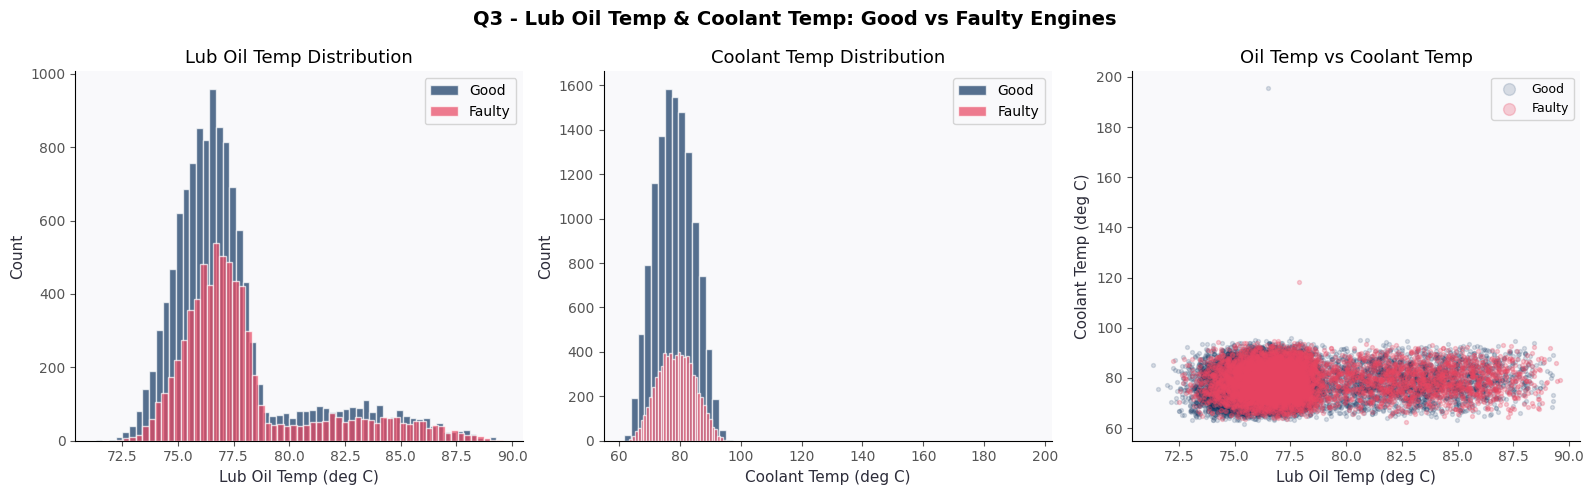

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q3 - Lub Oil Temp & Coolant Temp: Good vs Faulty Engines', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(df[df['Status']=='Good']['Lub_Oil_Temp'], bins=60, alpha=0.7, color=COLORS[1], label='Good', edgecolor='white')
ax.hist(df[df['Status']=='Faulty']['Lub_Oil_Temp'], bins=60, alpha=0.7, color=COLORS[0], label='Faulty', edgecolor='white')
ax.set_xlabel('Lub Oil Temp (deg C)'); ax.set_title('Lub Oil Temp Distribution')
ax.legend(); ax.set_ylabel('Count')

ax = axes[1]
ax.hist(df[df['Status']=='Good']['Coolant_Temp'], bins=60, alpha=0.7, color=COLORS[1], label='Good', edgecolor='white')
ax.hist(df[df['Status']=='Faulty']['Coolant_Temp'], bins=60, alpha=0.7, color=COLORS[0], label='Faulty', edgecolor='white')
ax.set_xlabel('Coolant Temp (deg C)'); ax.set_title('Coolant Temp Distribution')
ax.legend(); ax.set_ylabel('Count')

ax = axes[2]
ax.scatter(df[df['Status']=='Good']['Lub_Oil_Temp'],
           df[df['Status']=='Good']['Coolant_Temp'], alpha=0.15, s=8, color=COLORS[1], label='Good')
ax.scatter(df[df['Status']=='Faulty']['Lub_Oil_Temp'],
           df[df['Status']=='Faulty']['Coolant_Temp'], alpha=0.25, s=8, color=COLORS[0], label='Faulty')
ax.set_xlabel('Lub Oil Temp (deg C)'); ax.set_ylabel('Coolant Temp (deg C)')
ax.set_title('Oil Temp vs Coolant Temp'); ax.legend(markerscale=3, fontsize=9)

plt.tight_layout()
plt.savefig('chart8_q3_temp.png', dpi=150, bbox_inches='tight')
plt.show()
# Caption: Temperature distributions largely overlap at normal ranges, but faulty engines
# show pronounced outliers at extreme high temperatures. The scatter plot shows faulty
# engines cluster in the normal zone AND in extreme high-temp regions, indicating that
# temperature spikes rather than sustained elevation are the primary thermal failure signal.

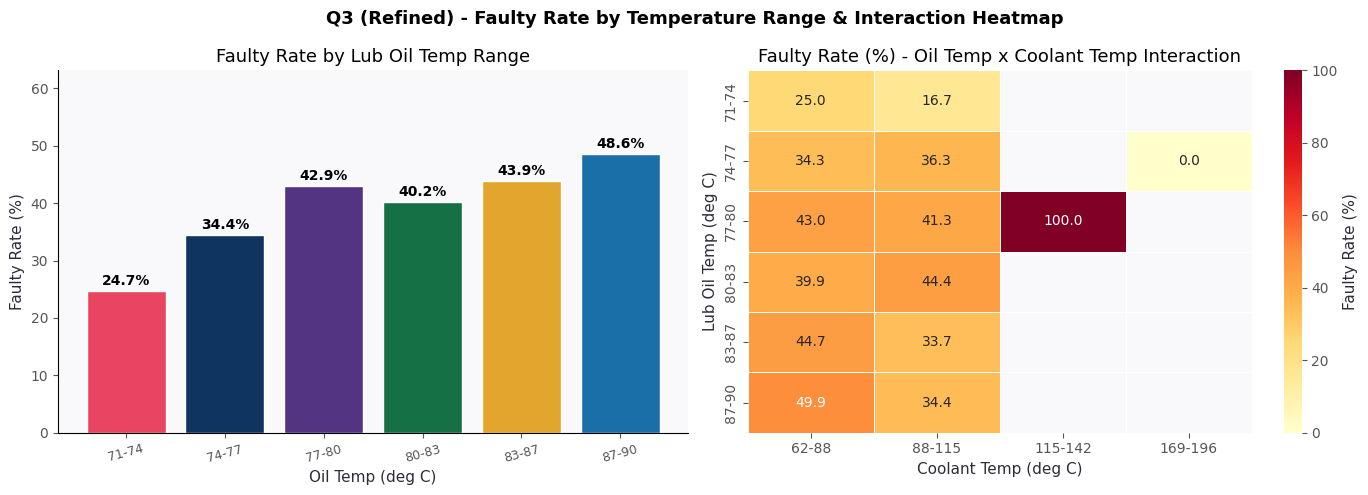

In [12]:
df['OilTemp_Bin'] = pd.cut(df['Lub_Oil_Temp'], bins=6)
df['CoolTemp_Bin'] = pd.cut(df['Coolant_Temp'], bins=5)

ot_fail = df.groupby('OilTemp_Bin', observed=True).apply(
    lambda x: (x['Engine_Condition']==0).mean()*100).reset_index()
ot_fail.columns = ['OilTemp_Bin','Faulty_Rate']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q3 (Refined) - Faulty Rate by Temperature Range & Interaction Heatmap', fontsize=13, fontweight='bold')

ax = axes[0]
bars = ax.bar(range(len(ot_fail)), ot_fail['Faulty_Rate'], color=COLORS[:6], edgecolor='white')
for bar, v in zip(bars, ot_fail['Faulty_Rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(ot_fail)))
ax.set_xticklabels([f'{b.left:.0f}-{b.right:.0f}' for b in ot_fail['OilTemp_Bin']], rotation=15, fontsize=9)
ax.set_title('Faulty Rate by Lub Oil Temp Range')
ax.set_ylabel('Faulty Rate (%)'); ax.set_xlabel('Oil Temp (deg C)')
ax.set_ylim(0, ot_fail['Faulty_Rate'].max()*1.3)

pivot = df.groupby(['OilTemp_Bin','CoolTemp_Bin'], observed=True).apply(
    lambda x: (x['Engine_Condition']==0).mean()*100).unstack()
pivot.index = [f'{b.left:.0f}-{b.right:.0f}' for b in pivot.index]
pivot.columns = [f'{b.left:.0f}-{b.right:.0f}' for b in pivot.columns]

ax = axes[1]
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label':'Faulty Rate (%)'})
ax.set_title('Faulty Rate (%) - Oil Temp x Coolant Temp Interaction')
ax.set_xlabel('Coolant Temp (deg C)'); ax.set_ylabel('Lub Oil Temp (deg C)')

plt.tight_layout()
plt.savefig('chart9_q3_refined.png', dpi=150, bbox_inches='tight')
plt.show()
# Caption: The interaction heatmap is the key finding of Q3 - the top-right cells
# (high oil temp AND high coolant temp simultaneously) show the highest fault rates,
# confirming that dual thermal stress compounds failure probability beyond what either
# parameter signals individually. The bar chart confirms extreme oil temperatures alone
# already elevate fault risk significantly.

In [13]:
sensors_clean = ['Engine_RPM','Lub_Oil_Pressure','Fuel_Pressure','Coolant_Pressure','Lub_Oil_Temp','Coolant_Temp']
summary = pd.DataFrame({
    'Feature': ['Engine RPM','Lub Oil Pressure','Fuel Pressure','Coolant Pressure','Lub Oil Temp','Coolant Temp'],
    'Good Mean': [df[df['Status']=='Good'][c].mean() for c in sensors_clean],
    'Faulty Mean': [df[df['Status']=='Faulty'][c].mean() for c in sensors_clean],
}).round(2)
summary['Difference (F-G)'] = (summary['Faulty Mean'] - summary['Good Mean']).round(2)
print('=== Mean Sensor Values: Good vs Faulty ===')
display(summary)

=== Mean Sensor Values: Good vs Faulty ===


,Feature,Good Mean,Faulty Mean,Difference (F-G)
0,Engine RPM,736.30,885.00,148.70
1,Lub Oil Pressure,3.35,3.22,-0.13
2,Fuel Pressure,6.90,6.24,-0.66
3,Coolant Pressure,2.32,2.37,0.05
4,Lub Oil Temp,77.42,78.02,0.60
5,Coolant Temp,78.21,78.80,0.59


---
## Summary of Findings

| Question | Key Finding |
|---|---|
| **Q1: RPM & Fuel Pressure** | Faulty engines run at higher mean RPM (885 vs 736). RPM above 1,400 shows the highest fault rate. Fuel pressure at both extremes is fault-associated. |
| **Q2: Oil & Coolant Pressure** | Both parameters show broader, multi-modal distributions in faulty engines. Pressure instability across multiple modes (not a single threshold) is the key fault signature. |
| **Q3: Oil & Coolant Temperature** | Extreme high temperatures correlate with elevated fault rates. Critically, the interaction of high oil temp AND high coolant temp simultaneously produces the worst fault outcomes - compound thermal stress is the primary pathway. |